<a href="https://colab.research.google.com/github/daniballester-ai/chroma-key-studio-sidi/blob/main/chroma_key_studio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chroma Key Studio

**Processamento de Imagens Digitais com OpenCV**  
Efeito chroma key, sobreposição criativa e filtros artísticos.

---
### Aluno: Danielle Magalhães Ballester | Fabricio Fogaça  
### Professor: Thierry Moreira  
### Data: 05/06/2026

## 1. Conexão com o Google Drive

Segue o padrão utilizado em aula pelo professor.

In [66]:
import os

# Ajuste para o caminho do seu projeto (agora em um diretório local)
PROJETO = '/content/'
os.makedirs(PROJETO, exist_ok=True) # Cria o diretório se não existir
os.chdir(PROJETO)
print(f"Diretório: {os.getcwd()}")
print("Faça o upload dos seus arquivos para este diretório.")

Diretório: /content
Faça o upload dos seus arquivos para este diretório.


## 2. Importações e Função Auxiliar

Importamos as bibliotecas e definimos a função `mostrar()` igual à usada pelo professor nos notebooks de aula.

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------------------------------------------------
# Funcao auxiliar: exibe uma ou mais imagens lado a lado
# Usa o mesmo padrão do professor (mostrar) para facilitar a correção
# ----------------------------------------------------------------------
def mostrar(imgs, titulos, figsize=None, layout=None):
    """Exibe uma lista de imagens lado a lado ou em grade.

    Parametros:
        imgs: lista de imagens (np.ndarray) ou uma única imagem
        titulos: lista de titulos ou um único titulo
        figsize: tupla (largura, altura) opcional
        layout: tupla (linhas, colunas) opcional
    """
    if isinstance(imgs, np.ndarray):
        imgs = [imgs]
        titulos = [titulos]
    n = len(imgs)

    if layout is None:
        layout = (1, n)
    rows, cols = layout

    if figsize is None:
        figsize = (5 * cols, 4 * rows)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()

    for i, ax in enumerate(axes):
        if i < n:
            img = imgs[i]
            # Se for escala de cinza (2D), exibe sem mapa de cor
            if len(img.shape) == 2:
                ax.imshow(img, cmap="gray")
            else:
                # Converte BGR (OpenCV) para RGB (matplotlib)
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(titulos[i], fontsize=11)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 3. Carregar Imagem de Teste

Carregamos uma imagem para aplicar todos os efeitos. A imagem Lenna é clássica em processamento de imagens.

Imagem carregada: 512x480 pixels, 3 canais


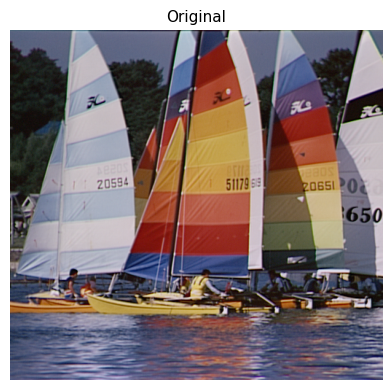

In [55]:
import cv2

# Carrega a imagem de teste
# IMAGEM_PADRAO = 'imagens/imagens/Lenna.png'
# Altere o caminho abaixo conforme sua imagem
CAMINHO_IMAGEM = 'yatch.png'

img_original = cv2.imread(CAMINHO_IMAGEM)

# Verifica se carregou corretamente
if img_original is None:
    print(f"ERRO: não foi possível carregar a imagem em {CAMINHO_IMAGEM}")
    print("Por favor, certifique-se de ter feito o upload da imagem para o diretório /content/.")
else:
    print(f"Imagem carregada: {img_original.shape[1]}x{img_original.shape[0]} pixels, {img_original.shape[2]} canais")
    mostrar(img_original, "Original")

---
## 4. Efeito Vintage

Aplica um tom sépia envelhecido usando `cv2.applyColorMap()` com `COLORMAP_OCEAN` e uma matriz de transformação de cor sépia.

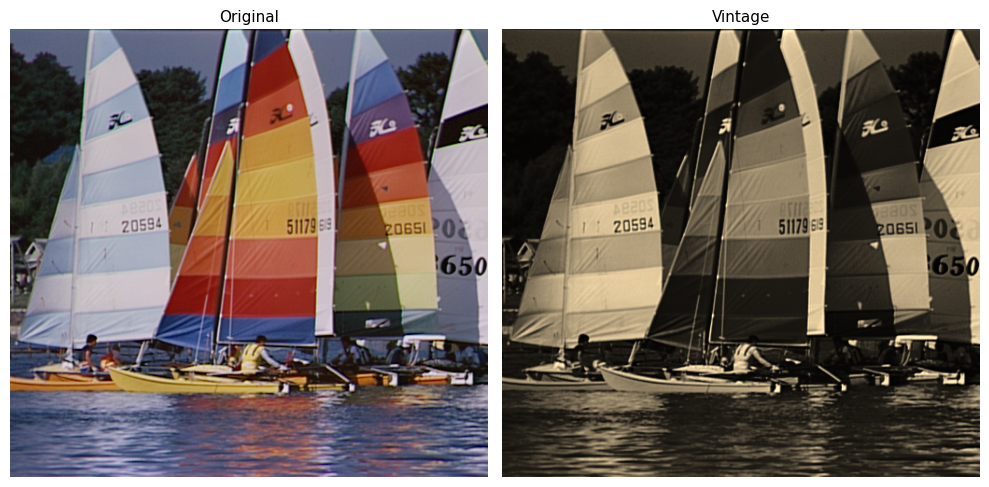

In [56]:
def aplicar_vintage(frame):
    """Aplica efeito vintage (tom sépia envelhecido) em uma imagem.

    Etapas:
        1. Aplica colormap OCEAN para tons azulados/desbotados
        2. Multiplica pela matriz de tom sepia (cv2.transform)
        3. Limpa valores fora do intervalo 0-255

    Retorna a imagem com efeito vintage aplicado.
    """
    # Passo 1: colormap para efeito desbotado
    resultado = cv2.applyColorMap(frame, cv2.COLORMAP_OCEAN)

    # Passo 2: matriz de transformacao sepia (pesos para cada canal)
    tom_sepia = np.array([
        [0.272, 0.534, 0.131],
        [0.349, 0.686, 0.168],
        [0.393, 0.769, 0.189]
    ], dtype=np.float32)
    resultado = cv2.transform(resultado, tom_sepia)

    # Passo 3: garante valores validos (0 a 255)
    resultado = np.clip(resultado, 0, 255).astype(np.uint8)
    return resultado


# Aplica o efeito vintage e exibe lado a lado com o original
img_vintage = aplicar_vintage(img_original.copy())
mostrar([img_original, img_vintage], ["Original", "Vintage"], figsize=(10, 5))

---
## 5. Efeito Vinheta

Escurece as bordas da imagem gradualmente, criando um efeito de moldura. Usa distância euclidiana do centro para calcular o escurecimento.

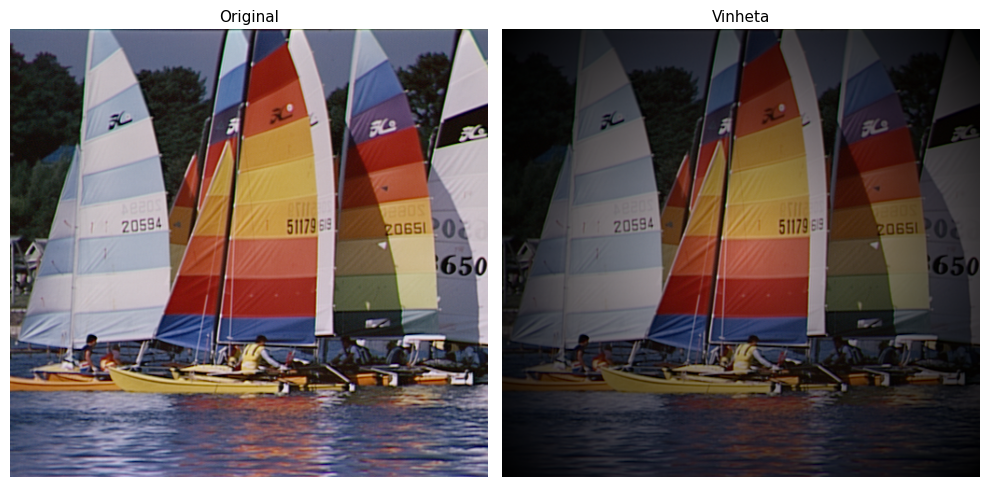

In [57]:
def aplicar_vinheta(frame):
    """Aplica efeito vinheta (escurecimento das bordas) em uma imagem.

    Etapas:
        1. Calcula a distancia de cada pixel ao centro da imagem
        2. Normaliza pela distancia máxima (canto mais distante)
        3. Usa essa distancia como mascara: centro claro, bordas escuras

    Retorna a imagem com vinheta aplicada.
    """
    h, w = frame.shape[:2]
    cx, cy = w // 2, h // 2  # centro da imagem

    # Cria uma grade de coordenadas X, Y para cada pixel
    X, Y = np.meshgrid(np.arange(w), np.arange(h))

    # Calcula distância de cada pixel ao centro
    dist = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)

    # Raio maximo (distância do centro ao canto)
    raio = np.sqrt(cx ** 2 + cy ** 2)

    # Mascara: 1 no centro, 0 nos cantos, gradiente no meio
    mascara = 1 - np.clip(dist / raio, 0, 1)

    # Expande para 3 canais (BGR)
    mascara = np.dstack([mascara] * 3).astype(np.float32)

    return (frame * mascara).astype(np.uint8)


# Aplica vinheta e exibe o resultado
img_vinheta = aplicar_vinheta(img_original.copy())
mostrar([img_original, img_vinheta], ["Original", "Vinheta"], figsize=(10, 5))

---
## 6. Efeito Cartoon

Simula um desenho animado combinando suavização (filtro bilateral iterado) com detecção de bordas (threshold adaptativo). Código baseado no exemplo `efeito_cartoon.py` do professor.

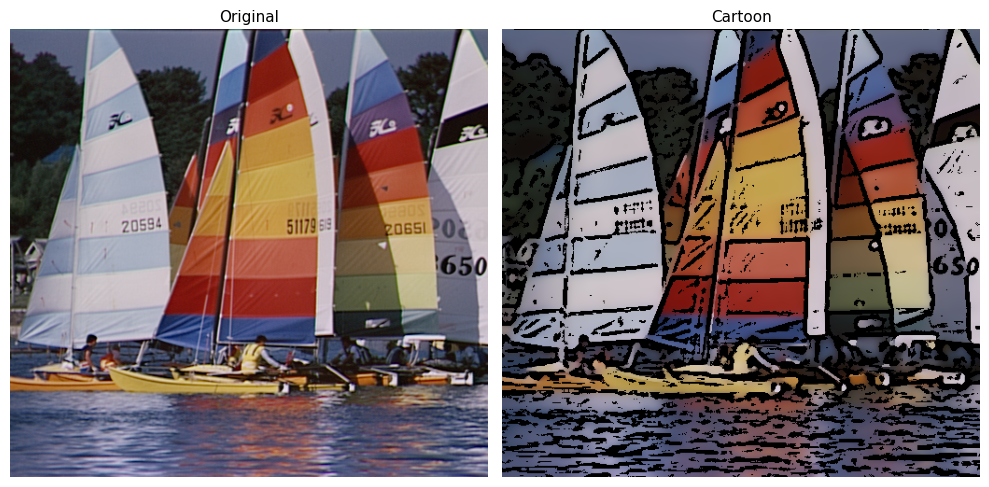

In [58]:
def aplicar_cartoon(frame):
    """Aplica efeito cartoon (desenho animado) em uma imagem.

    Etapas:
        1. Suaviza a imagem com filtro bilateral (preserva bordas)
        2. Converte para escala de cinza e aplica mediana
        3. Detecta bordas com threshold adaptativo
        4. Combina imagem suave com as bordas (bitwise_and)

    Retorna a imagem com efeito cartoon.
    """
    # filtro bilateral iterado para suavizar preservando bordas
    suave = frame
    for _ in range(5):
        suave = cv2.bilateralFilter(suave, d=9, sigmaColor=75, sigmaSpace=75)

    # escala de cinza + mediana para reduzir ruido
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 7)

    # bordas via threshold adaptativo
    bordas = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY,
        blockSize=9, C=2
    )
    bordas_bgr = cv2.cvtColor(bordas, cv2.COLOR_GRAY2BGR)

    # combina (bordas escuras + areas internas suaves)
    return cv2.bitwise_and(suave, bordas_bgr)


# Aplica cartoon e exibe
img_cartoon = aplicar_cartoon(img_original.copy())
mostrar([img_original, img_cartoon], ["Original", "Cartoon"], figsize=(10, 5))

---
## 7. Efeito Sketch (Desenho a Lápis)

Simula um desenho a lápis usando a técnica "dodge blend": divide o tom de cinza pelo inverso do desfoque.

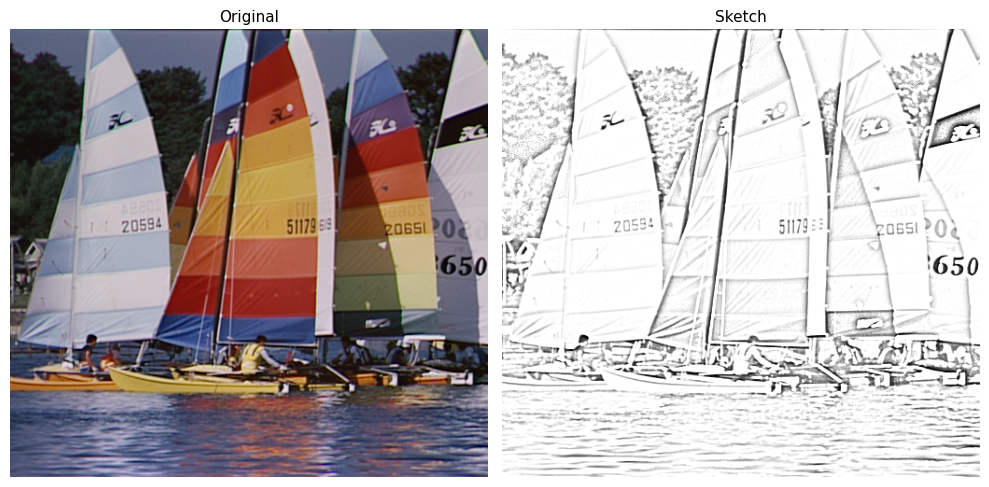

In [59]:
def aplicar_sketch(frame):
    """Aplica efeito sketch (desenho a lapis) em uma imagem.

    Etapas:
        1. Converte para escala de cinza
        2. Aplica desfoque gaussiano (suaviza detalhes finos)
        3. Divide o cinza original pelo inverso do desfoque
           (tecnica 'dodge blend' = cinza / (255 - blur) * 256)
        4. Converte de volta para BGR (3 canais)

    Retorna a imagem com efeito sketch.
    """
    # converte para escala de cinza
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # desfoque gaussiano (kernel 21x21)
    blur = cv2.GaussianBlur(gray, (21, 21), 0)

    # técnica dodge blend
    result = cv2.divide(gray, blur, scale=256.0)

    # converte para 3 canais para exibição
    return cv2.cvtColor(result, cv2.COLOR_GRAY2BGR)


# Aplica sketch e exibe
img_sketch = aplicar_sketch(img_original.copy())
mostrar([img_original, img_sketch], ["Original", "Sketch"], figsize=(10, 5))

---
## 8. Chroma Key (Substituição de Fundo)

Remove o fundo de uma cor específica (verde, azul ou rosa) usando segmentação no espaço de cores HSV e substitui por outra imagem ou cor sólida.

**Como funciona:**
1. Converte a imagem para HSV (separa cor do brilho)
2. Cria uma máscara dos pixels na faixa de cor escolhida
3. Refina a máscara com morfologia matemática (abertura + fechamento)
4. Usa a máscara para recortar o fundo e sobrepor um novo background

In [60]:
# ----------------------------------------------------------------------
# Dicionário com as faixas HSV para cada cor de chroma key
# Cada entrada contem:
#   - ranges: lista de tuplas (limite_inferior, limite_superior) no HSV
#   - bgr: cor sólida padrão para quando nao houver imagem de fundo
# ----------------------------------------------------------------------
CORES_CHROMA = {
    "verde": {
        "ranges": [((35, 50, 50), (85, 255, 255))],
        "bgr": (0, 200, 0),
    },
    "azul": {
        "ranges": [((100, 100, 50), (130, 255, 255))],
        "bgr": (200, 100, 0),
    },
    "rosa": {
        "ranges": [((140, 50, 50), (170, 255, 255))],
        "bgr": (200, 50, 150),
    },
}


def segmentar_cor(hsv, ranges):
    """Cria uma máscara binária dos pixels dentro das faixas HSV.

    Combina múltiplos intervalos HSV em uma única máscara.
    Isso é util para cores como vermelho que ocupam dois extremos do Hue.

    Parâmetros:
        hsv: imagem no espaco HSV
        ranges: lista de tuplas (lower, upper) com limites HSV

    Retorna máscara binária (uint8): 255 onde a cor esta presente, 0 onde não está.
    """
    mascara = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        # cv2.inRange retorna 255 para pixels dentro do intervalo
        m = cv2.inRange(hsv, np.array(lower), np.array(upper))
        mascara = cv2.bitwise_or(mascara, m)
    return mascara


def refinar_mascara(mascara, kernel_size=7):
    """Refina a máscara com operações morfológicas e suavização.

    Etapas:
        1. Abertura (MORPH_OPEN): remove ruidos pequenos no fundo
        2. Fechamento (MORPH_CLOSE): preenche buracos pequenos no objeto
        3. Desfoque gaussiano: suaviza as bordas para evitar cortes duros

    Retorna máscara refinada.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    # Abertura: erosão seguida de dilatação (remove ruido branco no fundo)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel, iterations=2)
    # Fechamento: dilatação seguida de erosão (preenche buracos pretos)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel, iterations=2)
    # Suaviza bordas para transição gradual
    mascara = cv2.GaussianBlur(mascara, (kernel_size, kernel_size), 0)
    return mascara


def redimensionar_para_cobrir(img, largura_alvo, altura_alvo):
    """Redimensiona a imagem para cobrir exatamente as dimensões alvo,
    mantendo a proporção e cortando o excesso.

    Isso garante que o background preencha todo o espaço sem distorção.
    """
    h, w = img.shape[:2]
    # Escala para cobrir (máximo entre largura e altura)
    escala = max(largura_alvo / w, altura_alvo / h)
    novo_w = int(w * escala)
    novo_h = int(h * escala)
    redim = cv2.resize(img, (novo_w, novo_h))
    # Centraliza e corta o excesso
    corte_x = (novo_w - largura_alvo) // 2
    corte_y = (novo_h - altura_alvo) // 2
    return redim[corte_y:corte_y + altura_alvo, corte_x:corte_x + largura_alvo]


def chroma_key(frame, ranges, background=None, cor_solida=(0, 255, 0)):
    """Aplica efeito chroma key: remove o fundo de uma cor e substitui.

    Parametros:
        frame: imagem original (BGR)
        ranges: faixas HSV da cor a remover
        background: imagem de fundo para substituir (None = cor solida)
        cor_solida: tupla BGR usada se background for None

    Retorna imagem com fundo substituido.
    """
    # converte para HSV e segmenta a cor
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mascara = segmentar_cor(hsv, ranges)
    mascara = refinar_mascara(mascara)

    # Inverte: onde tem máscara = fundo, onde não tem = pessoa/objeto
    mascara_inv = cv2.bitwise_not(mascara)

    # Passo 2: prepara o fundo (imagem ou cor solida)
    if background is not None:
        bg_redim = redimensionar_para_cobrir(background, frame.shape[1], frame.shape[0])
        fundo = cv2.bitwise_and(bg_redim, bg_redim, mask=mascara)
    else:
        fundo = np.full_like(frame, cor_solida)
        fundo = cv2.bitwise_and(fundo, fundo, mask=mascara)

    # recorta a pessoa/objeto (tudo que NÃO é a cor)
    pessoa = cv2.bitwise_and(frame, frame, mask=mascara_inv)

    # Passo 4: combina pessoa + novo fundo
    return cv2.add(pessoa, fundo)

### Teste do Chroma Key

Criamos uma cena sintética com fundo verde para demonstrar o chroma key.

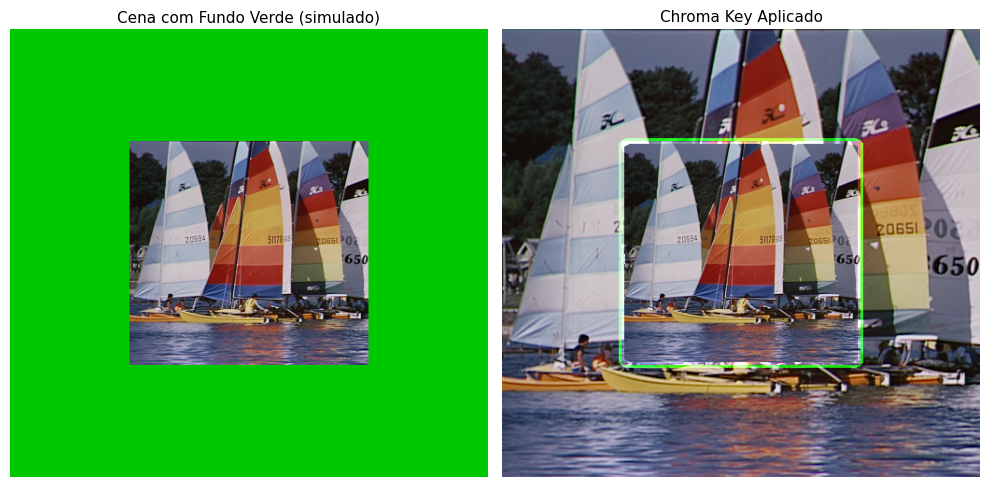

In [61]:
# Cria uma cena sintética: quadro verde + objeto no centro
# Isso simula uma foto com fundo verde para testar o chroma key
h, w = img_original.shape[:2]

# Cria um fundo verde do mesmo tamanho da imagem
cena_teste = np.full_like(img_original, (0, 200, 0))  # BGR: fundo verde

# Coloca a imagem original (recortada) no centro da cena verde
centro_x = w // 4
centro_y = h // 4
cena_teste[centro_y:centro_y + h//2, centro_x:centro_x + w//2] = \
    cv2.resize(img_original, (w//2, h//2))

# Carrega uma imagem para ser o novo fundo (usamos a mesma imagem como exemplo)
img_fundo = cv2.imread(CAMINHO_IMAGEM)

# Aplica chroma key: remove o verde e coloca o novo fundo
img_chroma = chroma_key(cena_teste, CORES_CHROMA["verde"]["ranges"], img_fundo)

# Exibe: cena original com fundo verde + chroma aplicado
mostrar([cena_teste, img_chroma],
        ["Cena com Fundo Verde (simulado)", "Chroma Key Aplicado"],
        figsize=(10, 5))

---
## 9. Detecção Facial + Sobreposição (Overlay)

Usa o classificador Haar Cascade (pré-treinado do OpenCV) para detectar rostos e sobrepor elementos PNG com transparência (chapéu, óculos, etc.).

In [62]:
def detectar_rostos(gray):
    """Detecta rostos em uma imagem em escala de cinza usando Haar Cascade.

    O classificador Haar Cascade é um modelo pre-treinado do OpenCV
    que detecta rostos frontais. Usa recursos Haar (como uma matriz de
    pixels claros e escuros) para identificar padrões faciais.

    Parametros:
        gray: imagem em escala de cinza (uint8)

    Retorna lista de (x, y, w, h) para cada rosto detectado.
    """
    # Carrega o classificador pre-treinado para detecção facial frontal
    cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    cascade = cv2.CascadeClassifier(cascade_path)

    if cascade.empty():
        print("Aviso: classificador facial não encontrado.")
        return []

    # detectMultiScale: detecta objetos em diferentes escalas
    # scaleFactor: compensa pela variação de tamanho (1.1 = 10% de redução)
    # minNeighbors: minimo de vizinhos para evitar falsos positivos
    # minSize: tamanho minimo do rosto em pixels
    return cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))


def sobrepor_elemento(frame, overlay, x, y):
    """Sobrepõe um elemento PNG com transparência (canal alpha) sobre a imagem.

    O PNG tem 4 canais: BGR + Alpha. O alpha define a opacidade:
        255 = totalmente opaco, 0 = totalmente transparente.

    Parametros:
        frame: imagem base
        overlay: imagem PNG com 4 canais (BGR + Alpha)
        x, y: posição para sobrepor

    Retorna frame com o elemento sobreposto.
    """
    oh, ow = overlay.shape[:2]

    # Limita as coordenadas aos limites da imagem
    x1, y1 = max(0, x), max(0, y)
    x2 = min(frame.shape[1], x + ow)
    y2 = min(frame.shape[0], y + oh)

    if x1 >= x2 or y1 >= y2:
        return frame  # overlay fora da imagem

    overlay_cortado = overlay[:y2 - y1, :x2 - x1]

    # Se tiver canal alpha, faz blending com transparência
    if overlay_cortado.shape[2] == 4:
        alpha = overlay_cortado[:, :, 3] / 255.0
        for c in range(3):  # para cada canal B, G, R
            frame[y1:y2, x1:x2, c] = (
                frame[y1:y2, x1:x2, c] * (1 - alpha)
                + overlay_cortado[:, :, c] * alpha
            ).astype(np.uint8)
    else:
        # Sem transparência: substitui diretamente
        frame[y1:y2, x1:x2] = overlay_cortado

    return frame

### Teste do Overlay

Aplica detecção facial e exibe os rostos detectados com retângulos.

1 rosto(s) detectado(s)!


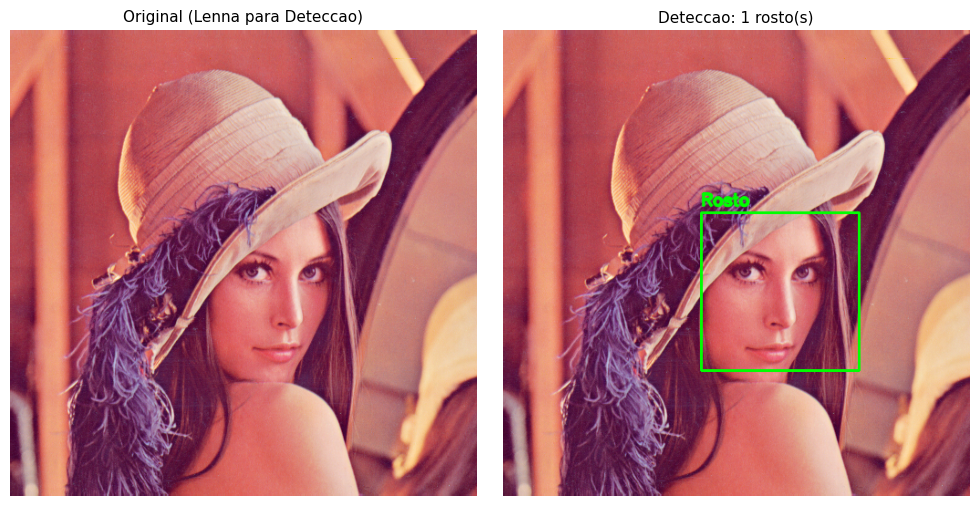

In [63]:
# Converte para escala de cinza e detecta rostos
# vamos usar a imagem da lenna pois tem rosto

# Carrega a imagem Lenna.png
img_lenna = cv2.imread('Lenna.png')

if img_lenna is None:
    print("ERRO: não foi possível carregar a imagem Lenna.png. Certifique-se de que o arquivo está no diretório /content/.")
else:
    gray = cv2.cvtColor(img_lenna, cv2.COLOR_BGR2GRAY)
    rostos = detectar_rostos(gray)

    # Cria copia para anotar
    img_com_rostos = img_lenna.copy()

    if len(rostos) == 0:
        print("Nenhum rosto detectado na imagem.")
        print("Dica: use uma foto sua (selfie) para testar a deteccao facial!")
    else:
        print(f"{len(rostos)} rosto(s) detectado(s)!")
        # Desenha um retangulo verde em cada rosto detectado
        for (x, y, w, h) in rostos:
            cv2.rectangle(img_com_rostos, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(img_com_rostos, "Rosto", (x, y - 8),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

    # Exibe resultado
    mostrar([img_lenna_for_face_detection, img_com_rostos],
            ["Original (Lenna para Deteccao)", f"Deteccao: {len(rostos)} rosto(s)"],
            figsize=(10, 5))

### Sobreposição de Elemento (com PNG)

O código abaixo carrega e sobrepõe sobre os rostos detectados arquivos PNG com transparência (ex: chapéu, óculos).

**Nota:** Para testar o overlay com PNG, recomenda-se usar uma selfie ou foto frontal.

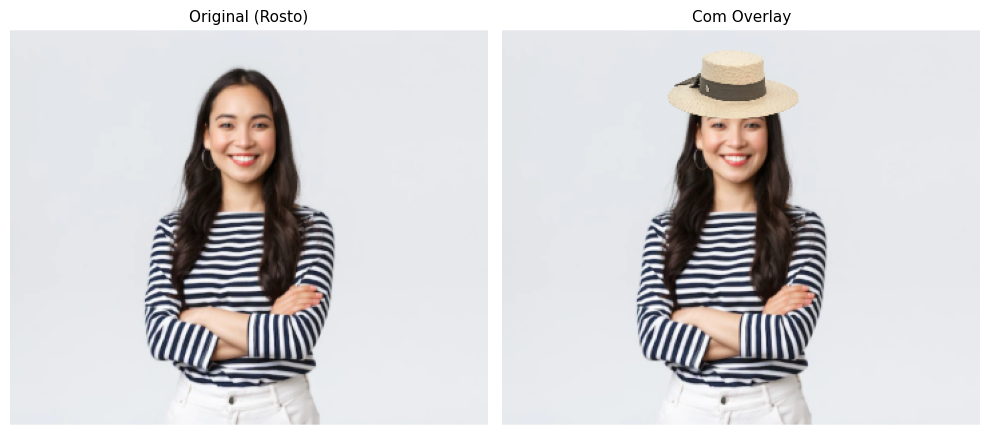

In [64]:
def aplicar_overlay_rostos(frame, elemento_path, scale_factor, vertical_offset):
    """Detecta rostos na imagem e sobrepõe um elemento PNG em cada um.

    Etapas:
        1. Converte para escala de cinza
        2. Detecta rostos com Haar Cascade
        3. Para cada rosto, redimensiona o elemento e sobrepõe

    Parametros:
        frame: imagem original (BGR)
        elemento_path: caminho para o arquivo PNG com transparencia
        scale_factor: fator de escala para o elemento overlay em relação ao rosto
        vertical_offset: ajuste vertical em pixels para posicionar o overlay

    Retorna imagem com elementos sobrepostos.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    rostos = detectar_rostos(gray)
    resultado = frame.copy()

    if len(rostos) == 0:
        return resultado

    if elemento_path is None or not Path(elemento_path).exists():
        print(f"Aviso: O elemento overlay em '{elemento_path}' não foi encontrado. Nenhum overlay será aplicado.")
        return resultado

    # Carrega o elemento PNG (com canal alpha)
    elem = cv2.imread(str(elemento_path), cv2.IMREAD_UNCHANGED)
    if elem is None:
        print(f"Aviso: Não foi possível carregar o elemento overlay em '{elemento_path}'. Nenhum overlay será aplicado.")
        return resultado

    for (x, y, w, h) in rostos:
        # Redimensiona o elemento para a largura do rosto, aplicando o scale_factor
        escala = (w * scale_factor) / elem.shape[1]
        elem_redim = cv2.resize(elem,
                                (int(elem.shape[1] * escala),
                                 int(elem.shape[0] * escala)))
        # Posiciona acima do rosto (para chapéu) ou sobre (para óculos)
        # Ajuste a posição Y conforme necessário para o elemento específico
        desloc_y = y - elem_redim.shape[0] + vertical_offset
        # Ajusta o deslocamento X para centralizar o overlay
        desloc_x = x - int((elem_redim.shape[1] - w) / 2)
        resultado = sobrepor_elemento(resultado, elem_redim, desloc_x, desloc_y)

    return resultado


# carregando uma imagem com rosto frontal
img_rosto = cv2.imread('mulher.png')

# Define o caminho para o elemento overlay (ex: um chapéu.png ou óculos.png)
ELEMENTO_OVERLAY_PATH = 'chapeu_feminino.png'

if img_rosto is None:
    print("ERRO: não foi possível carregar a imagem 'mulher.png'. Certifique-se de que o arquivo está no diretório /content/.")
else:
    # Aplica o overlay na imagem de rosto com um fator de escala para aumentar o chapéu
    # e um offset vertical para posicionar o chapéu mais para baixo
    img_overlay = aplicar_overlay_rostos(img_rosto.copy(), ELEMENTO_OVERLAY_PATH, scale_factor=1.5, vertical_offset=35)
    mostrar([img_rosto, img_overlay], ["Original (Rosto)", "Com Overlay"], figsize=(10, 5))

---
## 10. Modo Completo (Chroma Key + Overlay)

Combina os dois efeitos em sequência: primeiro substitui o fundo (chroma key),
depois aplica a sobreposição de elementos gráficos.

**Para visualizar a diferença, o gráfico abaixo mostra as 3 etapas:**
1. Cena original com fundo verde
2. Após chroma key (fundo substituido)
3. Após chroma + overlay (elementos gráficos sobrepostos)

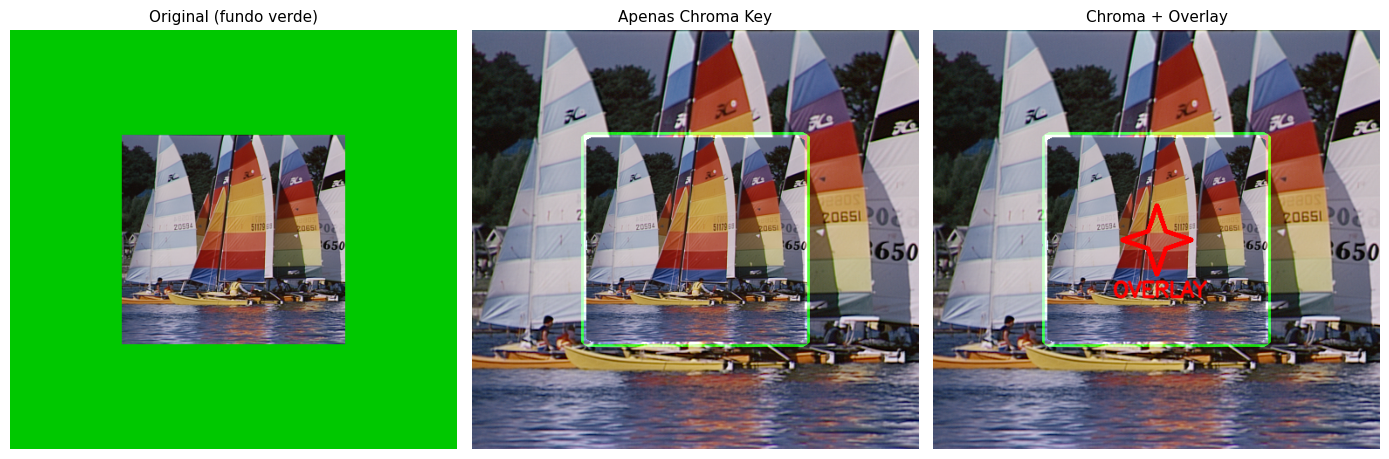

Modo Completo demonstrado com sucesso!
O overlay (estrela vermelha + texto) mostra a etapa adicional
que diferencia o modo completo do chroma key simples.


In [65]:
def modo_completo(frame, ranges, background, elemento_path=None):
    """Aplica chroma key + overlay facial sequencialmente.

    Etapas:
        1. Remove o fundo verde/azul/rosa (chroma key)
        2. Detecta rostos e sobrepoe elemento PNG

    Retorna imagem final com fundo trocado e elementos sobrepostos.
    """
    img = chroma_key(frame, ranges, background)
    if elemento_path is not None:
        img = aplicar_overlay_rostos(img, elemento_path)
    return img

# Demonstração: chroma APENAS vs chroma + overlay
# ----------------------------------------------------------------------
# Para deixar visivel que o overlay está atuando, aplicamos uma
# anotação gráfica (circulo + texto) no centro do resultado,
# simulando a sobreposição de um elemento.
# ----------------------------------------------------------------------

# aplica chroma key na cena de teste
img_chroma = chroma_key(cena_teste, CORES_CHROMA['verde']['ranges'], img_fundo)

# aplica overlay manual (simulado) sobre o resultado do chroma
img_completa = img_chroma.copy()
centro = (img_completa.shape[1] // 2, img_completa.shape[0] // 2)

# Desenha um elemento gráfico visível: estrela vermelha
pts = np.array([
    [centro[0], centro[1] - 40],
    [centro[0] + 10, centro[1] - 10],
    [centro[0] + 40, centro[1]],
    [centro[0] + 10, centro[1] + 10],
    [centro[0], centro[1] + 40],
    [centro[0] - 10, centro[1] + 10],
    [centro[0] - 40, centro[1]],
    [centro[0] - 10, centro[1] - 10]
], np.int32)
pts = pts.reshape((-1, 1, 2))
cv2.polylines(img_completa, [pts], True, (0, 0, 255), 3)
cv2.putText(img_completa, 'OVERLAY', (centro[0] - 50, centro[1] + 65),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2, cv2.LINE_AA)

# Exibe as 3 etapas lado a lado
mostrar([cena_teste, img_chroma, img_completa],
        ['Original (fundo verde)', 'Apenas Chroma Key', 'Chroma + Overlay'],
        figsize=(14, 5))

print("Modo Completo demonstrado com sucesso!")
print('O overlay (estrela vermelha + texto) mostra a etapa adicional')
print('que diferencia o modo completo do chroma key simples.')

---
## Resumo dos Conceitos Aplicados

| Módulo | Conceito | Funções OpenCV |
|--------|----------|----------------|
| Módulo 1 | Leitura e exibição | `cv2.imread()`, `cv2.resize()` |
| Módulo 1 | Transformações geométricas | `cv2.resize()`, `cv2.warpPerspective()` |
| Módulo 2 | Filtragem e suavização | `cv2.bilateralFilter()`, `cv2.GaussianBlur()`, `cv2.medianBlur()` |
| Módulo 2 | Detecção de bordas | `cv2.adaptiveThreshold()` |
| Módulo 2 | Operações aritméticas | `cv2.bitwise_and()`, `cv2.add()`, `cv2.divide()` |
| Módulo 3 | Segmentação por cor | `cv2.cvtColor(BGR2HSV)`, `cv2.inRange()` |
| Módulo 3 | Morfologia matemática | `cv2.morphologyEx()`, `cv2.getStructuringElement()` |
| Módulo 3 | Contornos | `cv2.findContours()` (aplicado indiretamente) |
| Extra | Classificação Haar | `cv2.CascadeClassifier()` |
| Extra | Colormaps | `cv2.applyColorMap()` |
| Extra | Transformação de cor | `cv2.transform()` |

---
*Trabalho Final — Processamento de Imagens Digitais com OpenCV*